# Learning Rate

In [2]:
# imports
import math
import numpy as np 

np.random.seed(67)

### Linear Rate Decay

Linear Rate Decay is given by:

$$l_r = \frac{l_{r_{\text{initial}}}}{1 + \text{decay} \times \text{epoch}}$$

In [2]:
"""
In practice, 0.1 would be considered a fairly aggressive decay rate, but this should give you a 
sense of the concept. If we are on step 20: 
"""
starting_learning_rate = 1. 
learning_rate_decay = 0.1 
step = 20 
 
learning_rate = starting_learning_rate * (1. / (1 + learning_rate_decay * step)) 
print(learning_rate)

0.3333333333333333


In [ ]:
"""
We can also simulate this in a loop, which is more comparable to how we will be applying 
learning rate decay: 
"""
starting_learning_rate = 1. 
learning_rate_decay = 0.1 
 
for step in range(20): 
    learning_rate = starting_learning_rate * (1. / (1 + learning_rate_decay * step)) 
    print(learning_rate)

1.0
0.9090909090909091
0.8333333333333334
0.7692307692307692
0.7142857142857143
0.6666666666666666
0.625
0.588235294117647
0.5555555555555556
0.5263157894736842
0.5
0.47619047619047616
0.45454545454545453
0.4347826086956522
0.41666666666666663
0.4
0.3846153846153846
0.37037037037037035
0.35714285714285715
0.3448275862068965


# Initialize Dense, ReLu, Loss

In [11]:
class Layer_Dense:
    def __init__(self, n_inputs, n_neurons):
        self.weights = 0.10 * np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))

    def forward(self, inputs):
        self.inputs = inputs 
        self.output = np.dot(inputs, self.weights) + self.biases

    def backward(self, dvalues):
        self.dweights = np.dot(self.inputs.T, dvalues)
        self.dbiases = np.sum(dvalues, axis=0, keepdims=True)
        self.dinputs = np.dot(dvalues, self.weights.T)

class Activation_ReLU: 
    def forward(self, inputs): 
        self.inputs = inputs 
        self.output = np.maximum(0, inputs) 

    def backward(self, dvalues): 
        self.dinputs = dvalues.copy() 
        self.dinputs[self.inputs <= 0] = 0 

class Loss: 
    def calculate(self, output, y): 
        sample_losses = self.forward(output, y) 
        data_loss = np.mean(sample_losses) 
        return data_loss 
 
class Loss_CategoricalCrossentropy(Loss): 
    def forward(self, y_pred, y_true): 
        samples = len(y_pred) 
        y_pred_clipped = np.clip(y_pred, 1e-7, 1 - 1e-7) 
        if len(y_true.shape) == 1: 
            correct_confidences = y_pred_clipped[ 
                range(samples), 
                y_true 
            ] 
        elif len(y_true.shape) == 2: 
            correct_confidences = np.sum( 
                y_pred_clipped * y_true, 
                axis=1 
            ) 
 
        negative_log_likelihoods = -np.log(correct_confidences) 
        return negative_log_likelihoods 
 
    def backward(self, dvalues, y_true): 
        samples = len(dvalues) 
        labels = len(dvalues[0]) 

        if len(y_true.shape) == 1: 
            y_true = np.eye(labels)[y_true] 
 
        self.dinputs = -y_true / dvalues 
        self.dinputs = self.dinputs / samples 

class Activation_Softmax: 
    def forward(self, inputs): 
        self.inputs = inputs 
        exp_values = np.exp(inputs - np.max(inputs, axis=1, keepdims=True)) 
        probabilities = exp_values / np.sum(exp_values, axis=1, keepdims=True) 
        self.output = probabilities 

    def backward(self, dvalues): 
        self.dinputs = np.empty_like(dvalues) 
 
        for index, (single_output, single_dvalues) in enumerate(zip(self.output, dvalues)): 
            single_output = single_output.reshape(-1, 1) 
            jacobian_matrix = np.diagflat(single_output) - np.dot(single_output, single_output.T) 

            self.dinputs[index] = np.dot(jacobian_matrix, 
                                         single_dvalues) 
 
class Activation_Softmax_Loss_CategoricalCrossentropy(): 
    def __init__(self): 
        self.activation = Activation_Softmax() 
        self.loss = Loss_CategoricalCrossentropy() 
 
    def forward(self, inputs, y_true): 
        self.activation.forward(inputs) 
        self.output = self.activation.output 
        return self.loss.calculate(self.output, y_true) 
 
    def backward(self, dvalues, y_true): 
 
        samples = len(dvalues) 
 
        if len(y_true.shape) == 2: 
            y_true = np.argmax(y_true, axis=1) 
 
        self.dinputs = dvalues.copy() 
        self.dinputs[range(samples), y_true] -= 1 
        self.dinputs = self.dinputs / samples 

# Using Decay

### Linear Rate Decay

Recall Linear Rate Decay is given by:

$$l_r = \frac{l_{r_{\text{initial}}}}{1 + \text{decay} \times \text{epoch}}$$

We apply it in the `Optimizer_SGD` class:

```python
class Optimizer_SGD: 
    def __init__(self, learning_rate=1., decay=0.): 
        self.learning_rate = learning_rate 
        self.current_learning_rate = learning_rate 
        self.decay = decay 
        self.iterations = 0 
 
    # Call once before any parameter updates 
    def pre_update_params(self): 
        if self.decay: 
            self.current_learning_rate = self.learning_rate * (1. / (1. + self.decay * self.iterations)) 
 
    # Update parameters 
    def update_params(self, layer): 
        layer.weights += -self.current_learning_rate * layer.dweights 
        layer.biases += -self.current_learning_rate * layer.dbiases 
 
    # Call once after any parameter updates 
    def post_update_params(self): 
        self.iterations += 1 
```

### Updating our for loop:
Using our methods, we update the current learning rate with our linear rate decay formula, then we update the weights and biases, finally update parameter step.

```python
# Update weights
# stochastic gradient optimizer
optimizer.pre_update_params() 
optimizer.update_params(dense1_layer) 
optimizer.update_params(output_layer) 
optimizer.post_update_params()
```

In [12]:
from nnfs.datasets import spiral_data

X, y_true = spiral_data(samples=100, classes=3)

class Optimizer_SGD: 
    def __init__(self, learning_rate=1., decay=0.): 
        self.learning_rate = learning_rate 
        self.current_learning_rate = learning_rate 
        self.decay = decay 
        self.iterations = 0 
 
    # Call once before any parameter updates 
    def pre_update_params(self): 
        if self.decay: 
            self.current_learning_rate = self.learning_rate * (1. / (1. + self.decay * self.iterations)) 
 
    # Update parameters 
    def update_params(self, layer): 
        layer.weights += -self.current_learning_rate * layer.dweights 
        layer.biases += -self.current_learning_rate * layer.dbiases 
 
    # Call once after any parameter updates 
    def post_update_params(self): 
        self.iterations += 1 



In [13]:
learning_rate = 1.0
decay = 1e-3
epochs = 10_000

# re-initialize fresh weights
dense1_layer = Layer_Dense(2, 64)
relu_activation = Activation_ReLU()
output_layer = Layer_Dense(64, 3)
loss_activation = Activation_Softmax_Loss_CategoricalCrossentropy()
optimizer = Optimizer_SGD(learning_rate=learning_rate, decay=decay) # optimizer

loss_history, accuracy_history, learning_rate_history = [], [], []

for epoch in range(epochs):
    # forward
    dense1_layer.forward(X)
    relu_activation.forward(dense1_layer.output)
    output_layer.forward(relu_activation.output)
    loss = loss_activation.forward(output_layer.output, y_true)

    predictions = np.argmax(loss_activation.output, axis=1)
    if len(y_true.shape) == 2:
        y_labels = np.argmax(y_true, axis=1)
    else:
        y_labels = y_true
    accuracy = np.mean(predictions == y_labels)

    # backward
    loss_activation.backward(loss_activation.output, y_true)
    output_layer.backward(loss_activation.dinputs)
    relu_activation.backward(output_layer.dinputs)
    dense1_layer.backward(relu_activation.dinputs)

    # Update weights
    # stochastic gradient optimizer
    optimizer.pre_update_params() 
    optimizer.update_params(dense1_layer) 
    optimizer.update_params(output_layer) 
    optimizer.post_update_params()

    if epoch % (epochs // 10) == 0:
        print(f"epoch: {epoch:>4} accuracy: {accuracy:>4} loss: {loss:.4f}")
    
    loss_history.append(loss)
    accuracy_history.append(accuracy)
    learning_rate_history.append(optimizer.current_learning_rate)



epoch:    0 accuracy: 0.36666666666666664 loss: 1.0967
epoch: 1000 accuracy: 0.5033333333333333 loss: 1.0350
epoch: 2000 accuracy: 0.5666666666666667 loss: 0.9903
epoch: 3000 accuracy: 0.5833333333333334 loss: 0.9625
epoch: 4000 accuracy: 0.6133333333333333 loss: 0.9223
epoch: 5000 accuracy: 0.64 loss: 0.8732
epoch: 6000 accuracy: 0.6566666666666666 loss: 0.8256
epoch: 7000 accuracy: 0.6933333333333334 loss: 0.7839
epoch: 8000 accuracy: 0.72 loss: 0.7408
epoch: 9000 accuracy: 0.73 loss: 0.7048


# Visualize Accuarcy/Loss History

With a decay of 1e-3 and learning rate of 1, we notice that it removes the sudden bounces over time compared to `neural-network-backprop.ipynb` graphs.

Final Values: Loss 0.6749762287690801 Accuracy 0.7433333333333333 Learning Rate 0.09091735612328393
Decay 0.001


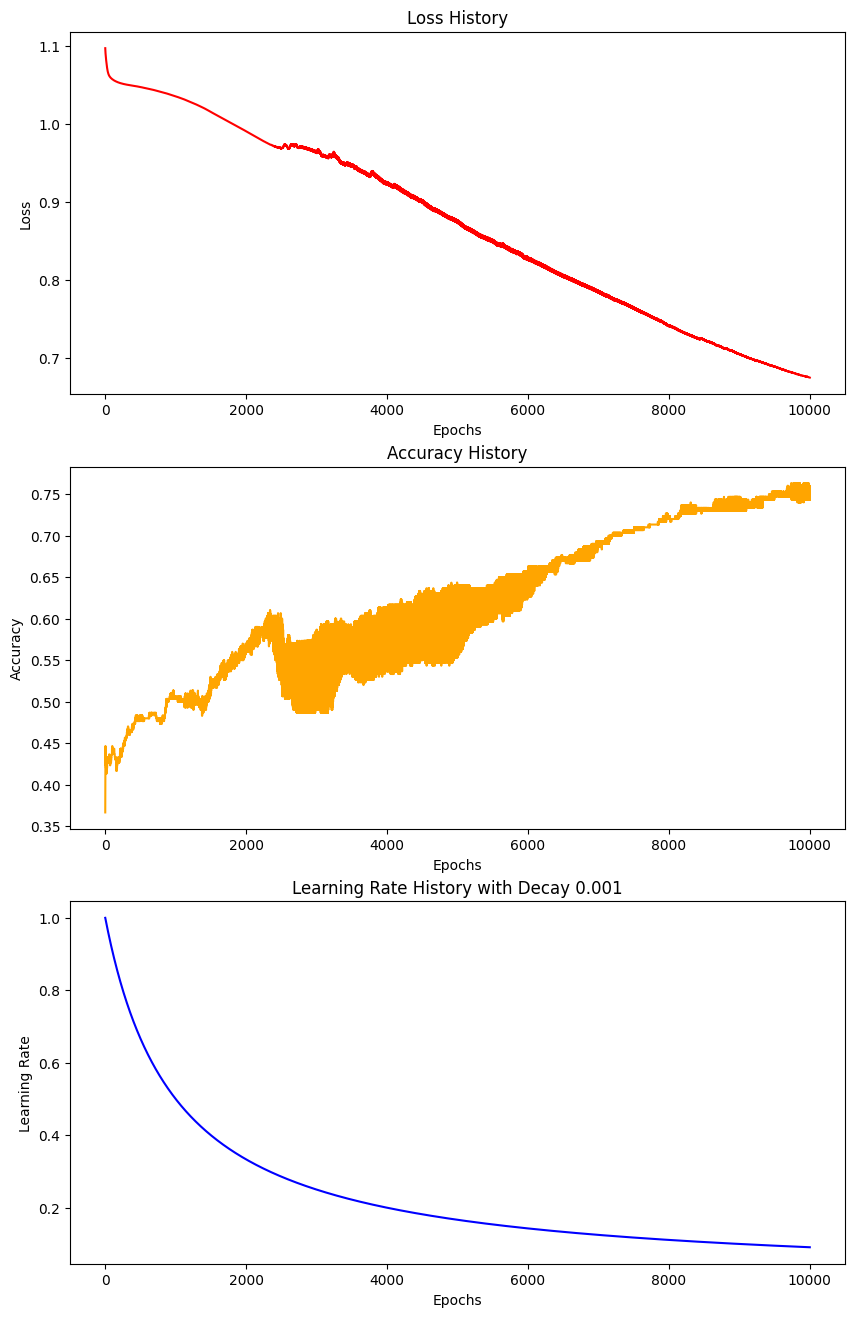

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=3, figsize=(10, 16))

axes[0].set_title("Loss History")
axes[0].plot(loss_history, color="red")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")

axes[1].set_title("Accuracy History")
axes[1].plot(accuracy_history, color="orange")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Accuracy")

axes[2].set_title(f"Learning Rate History with Decay {decay}")
axes[2].plot(learning_rate_history, color="blue")
axes[2].set_xlabel("Epochs")
axes[2].set_ylabel("Learning Rate")

print(f"Final Values: Loss {loss_history[-1]} Accuracy {accuracy_history[-1]} Learning Rate {learning_rate_history[-1]}")
print(f"Learning Rate {learning_rate} Decay {decay}")

# Utilizing Momentum

### Linear Rate Decay

Learning rate decay:
$$
l_r = \frac{l_{r_{\text{initial}}}}{1 + \text{decay} \times \text{epoch}}
$$

Momentum update:
$$
v_t = \beta v_{t-1} - l_r \nabla J(\theta_{t-1})
$$

Parameter update:
$$
\theta_t = \theta_{t-1} + v_t
$$

Combined:
$$
\text{update} = \text{momentum part} + \text{decayed gradient step}
$$

| Symbol | Meaning |
|-------|--------|
| $$\theta_t$$ | Parameters at step \(t\) |
| $$v_t$$ | Velocity (accumulated update) |
| $$\beta$$ | Momentum coefficient |
| $$l_r$$ | Current learning rate |
| $$l_{r_{\text{initial}}}$$ | Initial learning rate |
| $$\nabla J(\theta)$$ | Gradient of loss |

## Updating our `Optimizer_SGD`:

```python
    # Update parameters 
    ​def ​update_params​(​self​, ​layer​): 
 
        ​# If we use momentum 
        ​if ​self.momentum: 
 
            ​# If layer does not contain momentum arrays, create them 
            # filled with zeros 
            ​if not ​hasattr​(layer, ​'weight_momentums'​): 
                layer.weight_momentums ​= ​np.zeros_like(layer.weights) 
                ​# If there is no momentum array for weights 
                # The array doesn't exist for biases yet either. 
                ​layer.bias_momentums ​= ​np.zeros_like(layer.biases) 
 
            ​# Build weight updates with momentum - take previous 
            # updates multiplied by retain factor and update with 
            # current gradients 
            ​weight_updates ​= ​\ 
                self.momentum ​* ​layer.weight_momentums ​- ​\ 
                self.current_learning_rate ​* ​layer.dweights 
            layer.weight_momentums ​= ​weight_updates 
 
            ​# Build bias updates 
            ​bias_updates ​= ​\ 
                self.momentum ​* ​layer.bias_momentums ​- ​\ 
                self.current_learning_rate ​* ​layer.dbiases 
            layer.bias_momentums ​= ​bias_updates 
 
        ​# Vanilla SGD updates (as before momentum update) 
        ​else​: 
            weight_updates ​= -​self.current_learning_rate ​* ​\ 
                             layer.dweights 
            bias_updates ​= -​self.current_learning_rate ​* ​\ 
                           layer.dbiases 
 
        ​# Update weights and biases using either 
        # vanilla or momentum updates 
        ​layer.weights ​+= ​weight_updates 
        layer.biases ​+= ​bias_updates
```

In [15]:
from nnfs.datasets import spiral_data

X, y_true = spiral_data(samples=100, classes=3)

class Optimizer_SGD: 
    def __init__(self, learning_rate=1., decay=0., momentum=0.): 
        self.learning_rate = learning_rate 
        self.current_learning_rate = learning_rate 
        self.decay = decay 
        self.iterations = 0 
        self.momentum = momentum
 
    # Call once before any parameter updates 
    def pre_update_params(self): 
        if self.decay: 
            self.current_learning_rate = self.learning_rate * (1. / (1. + self.decay * self.iterations)) 
    
    # Update parameters 
    def update_params(self, layer): 
 
        # If we use momentum 
        if self.momentum: 
 
            # If layer does not contain momentum arrays, create them 
            # filled with zeros 
            if not hasattr(layer, 'weight_momentums'): 
                layer.weight_momentums = np.zeros_like(layer.weights) 
                # If there is no momentum array for weights 
                # The array doesn't exist for biases yet either. 
                layer.bias_momentums = np.zeros_like(layer.biases) 
 
            # Build weight updates with momentum - take previous 
            # updates multiplied by retain factor and update with 
            # current gradients 
            weight_updates = self.momentum * layer.weight_momentums - self.current_learning_rate * layer.dweights 
            layer.weight_momentums = weight_updates 
 
            # Build bias updates 
            bias_updates = self.momentum * layer.bias_momentums - self.current_learning_rate * layer.dbiases 
            layer.bias_momentums = bias_updates 
 
        # Vanilla SGD updates (as before momentum update) 
        else: 
            weight_updates = -self.current_learning_rate * layer.dweights 
            bias_updates = -self.current_learning_rate * layer.dbiases 
 
        # Update weights and biases using either 
        # vanilla or momentum updates 
        layer.weights += weight_updates 
        layer.biases += bias_updates

    # Call once after any parameter updates 
    def post_update_params(self): 
        self.iterations += 1 

    

# Initialize with Momentum

In [16]:
learning_rate = 1.0
decay = 1e-3
epochs = 10_000
momentum=0.9

# re-initialize fresh weights
dense1_layer = Layer_Dense(2, 64)
relu_activation = Activation_ReLU()
output_layer = Layer_Dense(64, 3)
loss_activation = Activation_Softmax_Loss_CategoricalCrossentropy()
optimizer = Optimizer_SGD(learning_rate=learning_rate, decay=decay, momentum=momentum) # optimizer

loss_history, accuracy_history, learning_rate_history = [], [], []

for epoch in range(epochs):
    # forward
    dense1_layer.forward(X)
    relu_activation.forward(dense1_layer.output)
    output_layer.forward(relu_activation.output)
    loss = loss_activation.forward(output_layer.output, y_true)

    predictions = np.argmax(loss_activation.output, axis=1)
    if len(y_true.shape) == 2:
        y_labels = np.argmax(y_true, axis=1)
    else:
        y_labels = y_true
    accuracy = np.mean(predictions == y_labels)

    # backward
    loss_activation.backward(loss_activation.output, y_true)
    output_layer.backward(loss_activation.dinputs)
    relu_activation.backward(output_layer.dinputs)
    dense1_layer.backward(relu_activation.dinputs)

    # Update weights
    # stochastic gradient optimizer
    optimizer.pre_update_params() 
    optimizer.update_params(dense1_layer) 
    optimizer.update_params(output_layer) 
    optimizer.post_update_params()

    if epoch % (epochs // 10) == 0:
        print(f"epoch: {epoch:>4} accuracy: {accuracy:>4} loss: {loss:.4f}")
    
    loss_history.append(loss)
    accuracy_history.append(accuracy)
    learning_rate_history.append(optimizer.current_learning_rate)



epoch:    0 accuracy: 0.34 loss: 1.0987
epoch: 1000 accuracy: 0.8933333333333333 loss: 0.2411
epoch: 2000 accuracy: 0.95 loss: 0.1353
epoch: 3000 accuracy: 0.9566666666666667 loss: 0.1211
epoch: 4000 accuracy: 0.9566666666666667 loss: 0.1110
epoch: 5000 accuracy: 0.96 loss: 0.1022
epoch: 6000 accuracy: 0.9633333333333334 loss: 0.0941
epoch: 7000 accuracy: 0.9666666666666667 loss: 0.0891
epoch: 8000 accuracy: 0.97 loss: 0.0845
epoch: 9000 accuracy: 0.97 loss: 0.0815


# Visualizing with Momentum

We observe that with our decay and momentum values has achieved 95% accuracy, where without momentum achieved ~88%.

Final Values: Loss 0.07906268499847714 Accuracy 0.97 Learning Rate 0.09091735612328393
Learning Rate 1.0 Decay 0.001 Momentum 0.9


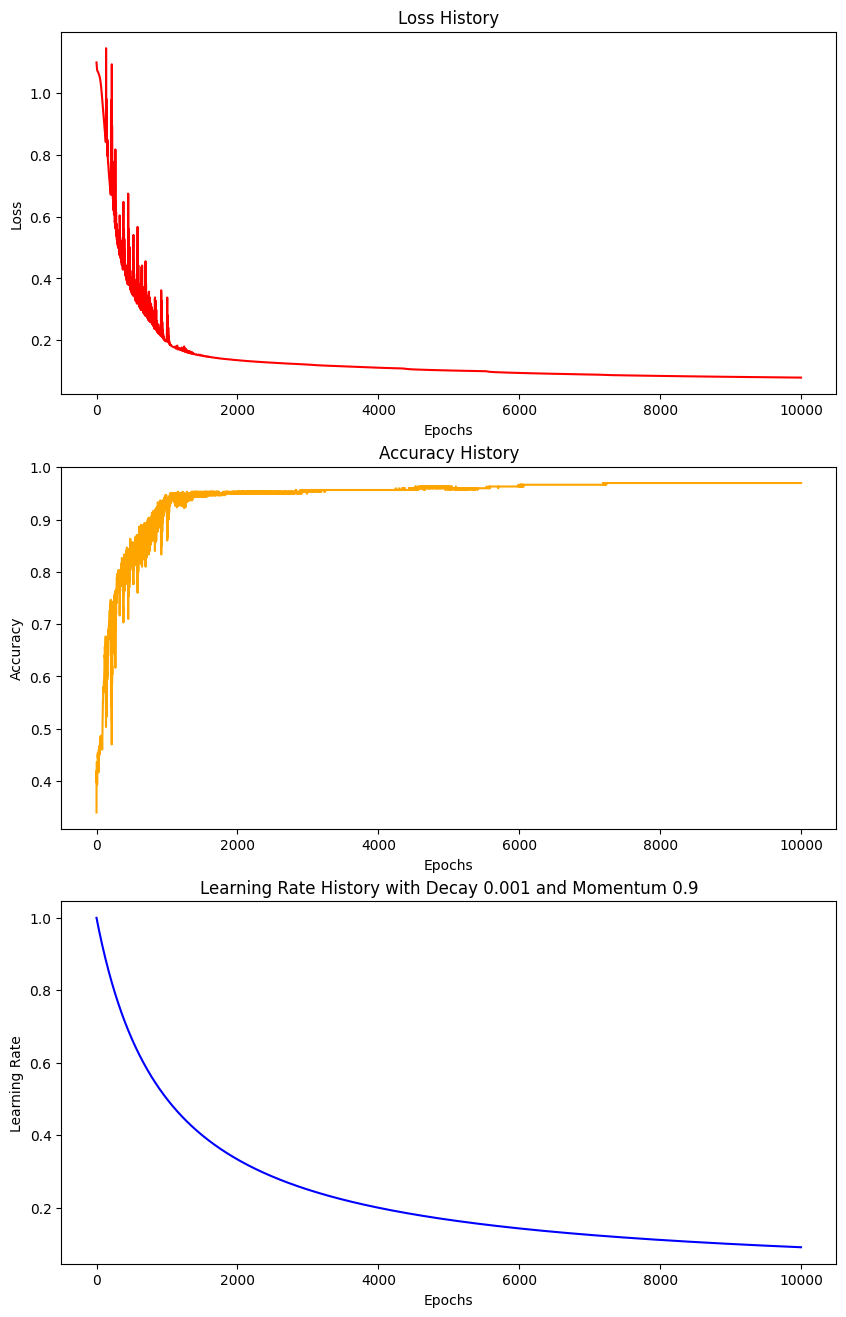

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=3, figsize=(10, 16))

axes[0].set_title("Loss History")
axes[0].plot(loss_history, color="red")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")

axes[1].set_title("Accuracy History")
axes[1].plot(accuracy_history, color="orange")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Accuracy")

axes[2].set_title(f"Learning Rate History with Decay {decay} and Momentum {momentum}")
axes[2].plot(learning_rate_history, color="blue")
axes[2].set_xlabel("Epochs")
axes[2].set_ylabel("Learning Rate")

print(f"Final Values: Loss {loss_history[-1]} Accuracy {accuracy_history[-1]} Learning Rate {learning_rate_history[-1]}")
print(f"Learning Rate {learning_rate} Decay {decay} Momentum {momentum}")